In [64]:
import struct
import numpy as np
import os

# Create directories
os.makedirs("../data/balanced", exist_ok=True)
os.makedirs("../data/noisy", exist_ok=True)

# Utils loaders
def load_idx_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def load_idx_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# Utils savers
def save_images_ubyte(images, path):
    N, H, W = images.shape
    with open(path, 'wb') as f:
        f.write(struct.pack('>IIII', 2051, N, H, W))
        f.write(images.tobytes())

def save_labels_ubyte(labels, path):
    N = labels.shape[0]
    with open(path, 'wb') as f:
        f.write(struct.pack('>II', 2049, N))
        f.write(labels.tobytes())

def rotate(images):
    images = np.array([np.rot90(np.fliplr(img)) for img in images])
    return images

train_images = load_idx_images('../data/original/emnist-byclass-train-images-idx3-ubyte')
train_labels = load_idx_labels('../data/original/emnist-byclass-train-labels-idx1-ubyte')
test_images = load_idx_images('../data/original/emnist-byclass-test-images-idx3-ubyte')
test_labels = load_idx_labels('../data/original/emnist-byclass-test-labels-idx1-ubyte')

train_images = rotate(train_images)
test_images = rotate(test_images)
mapping = {}
# Digits
for i in range(10):
    mapping[i] = str(i)
# Uppercase letters
for i in range(26):
    mapping[10 + i] = chr(65 + i)
# Lowercase letters
for i in range(26):
    mapping[36 + i] = chr(97 + i)

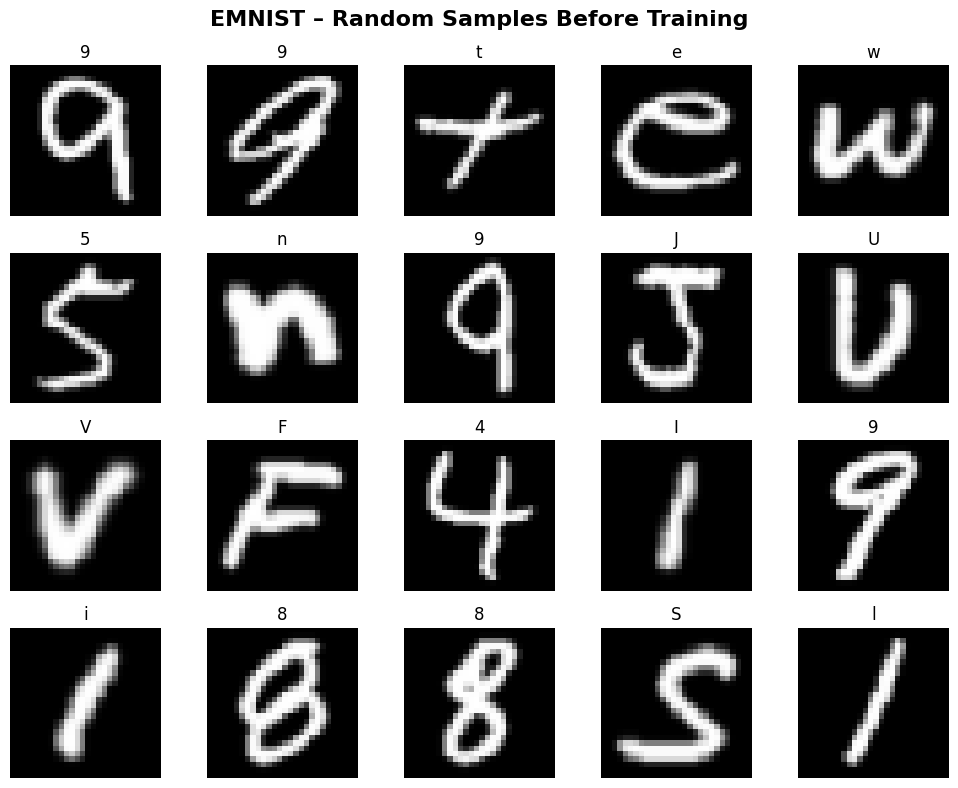

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Load 20 original samples randomly
num_samples = 20
indices = np.random.choice(len(train_images), num_samples, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(10, 8))
fig.suptitle("EMNIST – Random Samples Before Training", fontsize=16, fontweight='bold')

for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(train_images[idx], cmap='gray')
    label = mapping[train_labels[idx]]
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


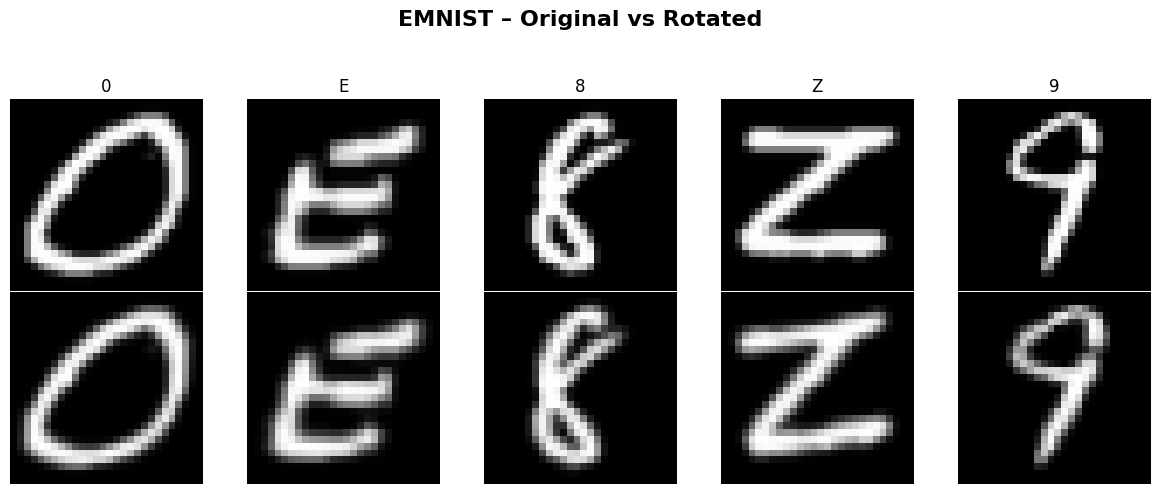

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Rotate 12 degrees randomly
def rotate_image(img, max_angle=12):
    angle = np.random.uniform(-max_angle, max_angle)
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderValue=0)

# Load 5 original samples and their rotated versions
indices = np.random.choice(len(train_images), 5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("EMNIST – Original vs Rotated", fontsize=16, fontweight='bold')

for i, idx in enumerate(indices):
    axes[0, i].imshow(train_images[idx], cmap='gray')
    axes[0, i].set_title(mapping[train_labels[idx]])
    axes[0, i].axis('off')

for i, idx in enumerate(indices):
    rotated = rotate_image(train_images[idx])
    axes[1, i].imshow(rotated, cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Rotated", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


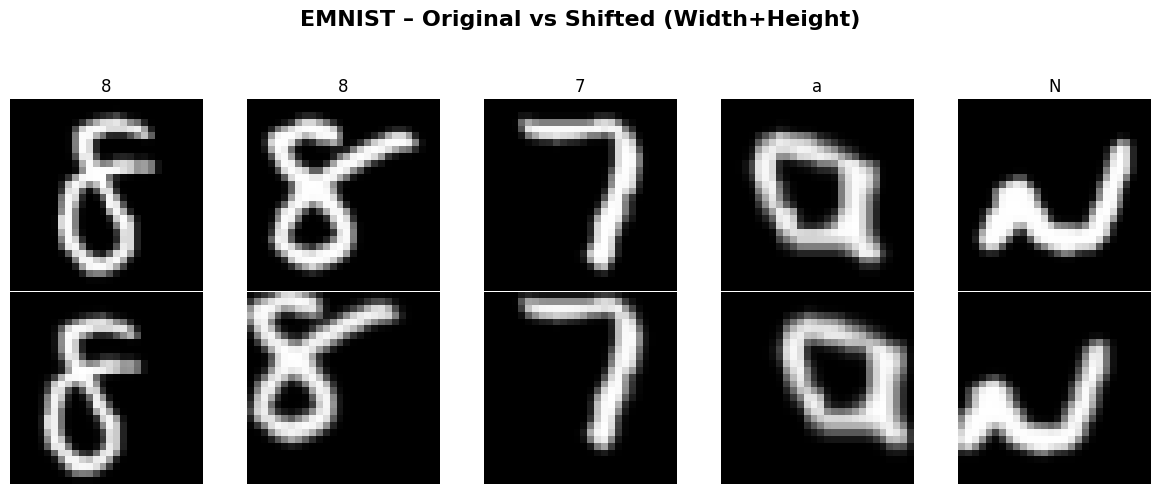

In [67]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Shift 15% randomly
def shift_images(img, width_shift_max=0.15, height_shift_max=0.15):
    h, w = img.shape
    tx = np.random.uniform(-width_shift_max, width_shift_max) * w
    ty = np.random.uniform(-height_shift_max, height_shift_max) * h
    
    M = np.float32([[1, 0, tx],
                    [0, 1, ty]])
    shifted = cv2.warpAffine(img, M, (w, h), borderValue=0)
    return shifted

# Load 5 original samples and their shifted versions
indices = np.random.choice(len(train_images), 5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12,5))
fig.suptitle("EMNIST – Original vs Shifted (Width+Height)", fontsize=16, fontweight='bold')

for i, idx in enumerate(indices):
    axes[0, i].imshow(train_images[idx], cmap='gray')
    axes[0, i].set_title(mapping[train_labels[idx]])
    axes[0, i].axis('off')

for i, idx in enumerate(indices):
    shifted = shift_images(train_images[idx])
    axes[1, i].imshow(shifted, cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Shifted", fontsize=12)

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()


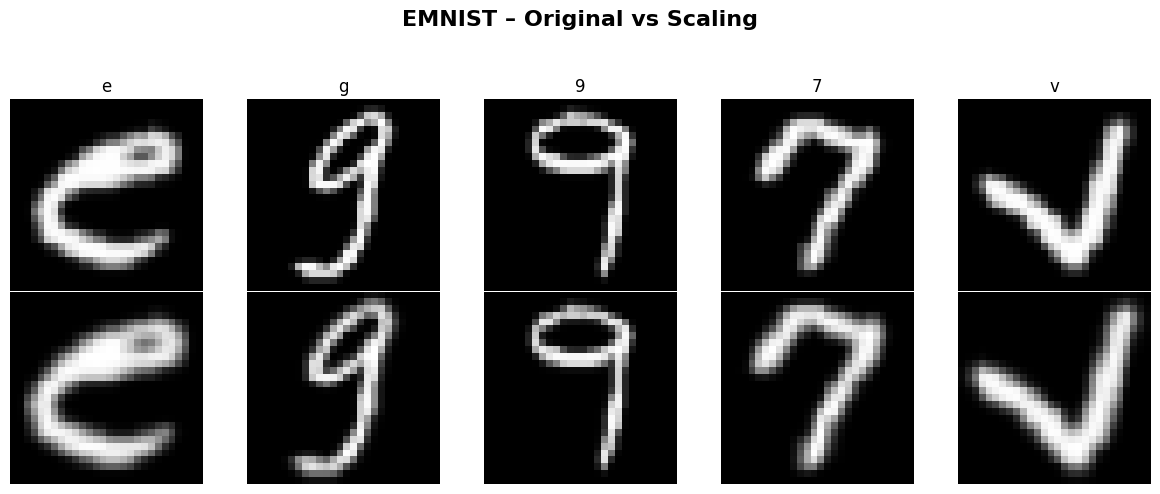

In [68]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Scale 12% randomly
def scale_image(img, max_scale=0.12):
    h, w = img.shape
    scale = 1 + np.random.uniform(-max_scale, max_scale)

    M = cv2.getRotationMatrix2D((w // 2, h // 2), 0, scale)

    return cv2.warpAffine(img, M, (w, h), borderValue=0)

# Load 5 original samples and their scaled versions
indices = np.random.choice(len(train_images), 5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("EMNIST – Original vs Scaling", fontsize=16, fontweight='bold')

for i, idx in enumerate(indices):
    axes[0, i].imshow(train_images[idx], cmap='gray')
    axes[0, i].set_title(mapping[train_labels[idx]])
    axes[0, i].axis('off')

for i, idx in enumerate(indices):
    scaled = scale_image(train_images[idx])
    axes[1, i].imshow(scaled, cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Scaled", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


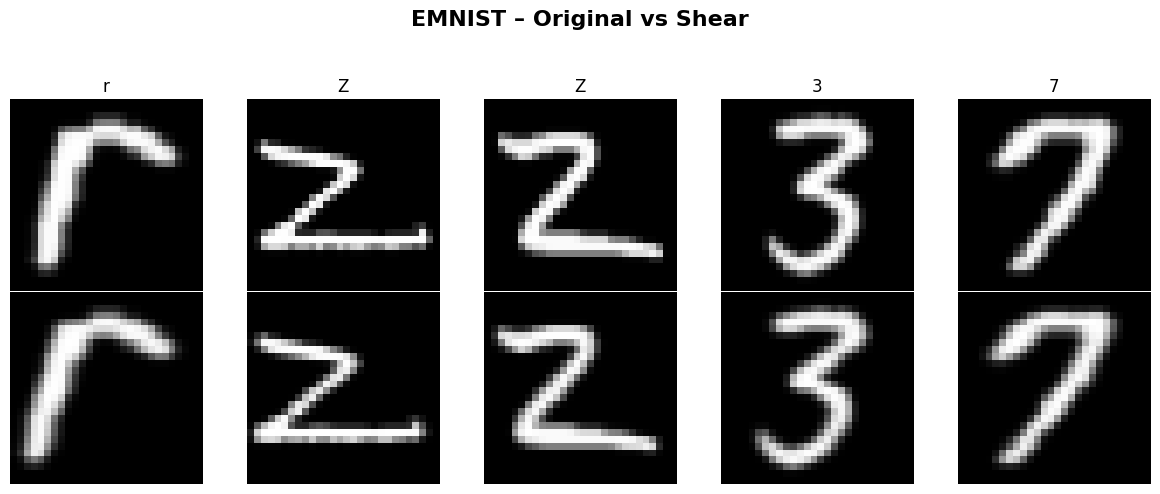

In [69]:
# Shear 10% randomly
def shear_image(img, shear_range=0.1):
    h, w = img.shape
    shear = np.random.uniform(-shear_range, shear_range)

    M = np.float32([[1, shear, 0],
                    [0,     1, 0]])

    return cv2.warpAffine(img, M, (w, h), borderValue=0)

# Load 5 original samples and their sheared versions
indices = np.random.choice(len(train_images), 5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("EMNIST – Original vs Shear", fontsize=16, fontweight='bold')

for i, idx in enumerate(indices):
    axes[0, i].imshow(train_images[idx], cmap='gray')
    axes[0, i].set_title(mapping[train_labels[idx]])
    axes[0, i].axis('off')

for i, idx in enumerate(indices):
    sheared = shear_image(train_images[idx])
    axes[1, i].imshow(sheared, cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Shear")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


Balanced target: 11256
Class 0 (0): train 34585 -> 11256, test 5778
Class 1 (1): train 38374 -> 11256, test 6330
Class 2 (2): train 34203 -> 11256, test 5869
Class 3 (3): train 35143 -> 11256, test 5969
Class 4 (4): train 33535 -> 11256, test 5619
Class 5 (5): train 31416 -> 11256, test 5190
Class 6 (6): train 34232 -> 11256, test 5705
Class 7 (7): train 35754 -> 11256, test 6139
Class 8 (8): train 33946 -> 11256, test 5633
Class 9 (9): train 33847 -> 11256, test 5686
Class 10 (A): train 6407 -> 11256, test 1062
Class 11 (B): train 3878 -> 11256, test 648
Class 12 (C): train 10094 -> 11256, test 1739
Class 13 (D): train 4562 -> 11256, test 779
Class 14 (E): train 4934 -> 11256, test 851
Class 15 (F): train 9182 -> 11256, test 1440
Class 16 (G): train 2517 -> 11256, test 447
Class 17 (H): train 3152 -> 11256, test 521
Class 18 (I): train 11946 -> 11256, test 2048
Class 19 (J): train 3762 -> 11256, test 626
Class 20 (K): train 2468 -> 11256, test 382
Class 21 (L): train 5076 -> 11256, te

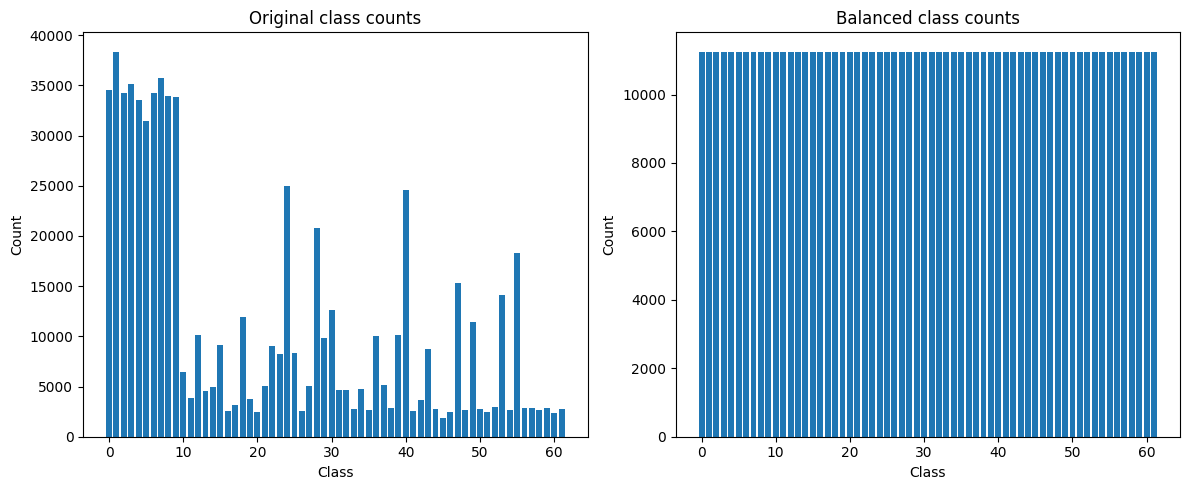


Saved balanced dataset:
Train: 697872 images
Test: 116323 images


In [70]:
balanced_target = train_images.shape[0] // 62
print("Balanced target:", balanced_target)

train_images_balanced = []
train_labels_balanced = []
test_images_balanced = []
test_labels_balanced = []

for cls in range(62):
    # Handle training data
    cls_train_indices = np.where(train_labels == cls)[0]
    cls_train_images = train_images[cls_train_indices]
    count = len(cls_train_indices)
    
    if count > balanced_target:
        selected = np.random.choice(cls_train_indices, balanced_target, replace=False)
        train_images_balanced.append(train_images[selected])
        train_labels_balanced.append(train_labels[selected])
    elif count < balanced_target:
        train_images_balanced.append(cls_train_images)
        train_labels_balanced.append(train_labels[cls_train_indices])
        needed = balanced_target - count
        while needed > 0:
            idx = np.random.choice(cls_train_indices)
            img = train_images[idx]
            op = np.random.choice([rotate_image, shear_image, scale_image, shift_images])
            new_img = op(img)
            train_images_balanced.append(np.expand_dims(new_img, 0))
            train_labels_balanced.append(np.array([cls]))
            needed -= 1
    else:
        train_images_balanced.append(cls_train_images)
        train_labels_balanced.append(train_labels[cls_train_indices])
    
    # Handle test data 
    cls_test_indices = np.where(test_labels == cls)[0]
    test_images_balanced.append(test_images[cls_test_indices])
    test_labels_balanced.append(test_labels[cls_test_indices])
    
    print(f"Class {cls} ({mapping[cls]}): train {count} -> {balanced_target}, test {len(cls_test_indices)}")

# Concatenate all data
train_images_balanced = np.concatenate(train_images_balanced, axis=0)
train_labels_balanced = np.concatenate(train_labels_balanced, axis=0)
test_images_balanced = np.concatenate(test_images_balanced, axis=0)
test_labels_balanced = np.concatenate(test_labels_balanced, axis=0)

# Plot distribution
original_counts = [np.sum(train_labels == i) for i in range(62)]
balanced_counts = [np.sum(train_labels_balanced == i) for i in range(62)]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.bar(range(62), original_counts)
plt.title("Original class counts")
plt.xlabel("Class")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.bar(range(62), balanced_counts)
plt.title("Balanced class counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Save balanced datasets
save_images_ubyte(train_images_balanced, "../data/balanced/emnist-byclass-train-images-idx3-ubyte")
save_labels_ubyte(train_labels_balanced, "../data/balanced/emnist-byclass-train-labels-idx1-ubyte")
save_images_ubyte(test_images_balanced, "../data/balanced/emnist-byclass-test-images-idx3-ubyte")
save_labels_ubyte(test_labels_balanced, "../data/balanced/emnist-byclass-test-labels-idx1-ubyte")

print(f"\nSaved balanced dataset:")
print(f"Train: {train_images_balanced.shape[0]} images")
print(f"Test: {test_images_balanced.shape[0]} images")

Applying background noise to training data...
Applying background noise to test data...


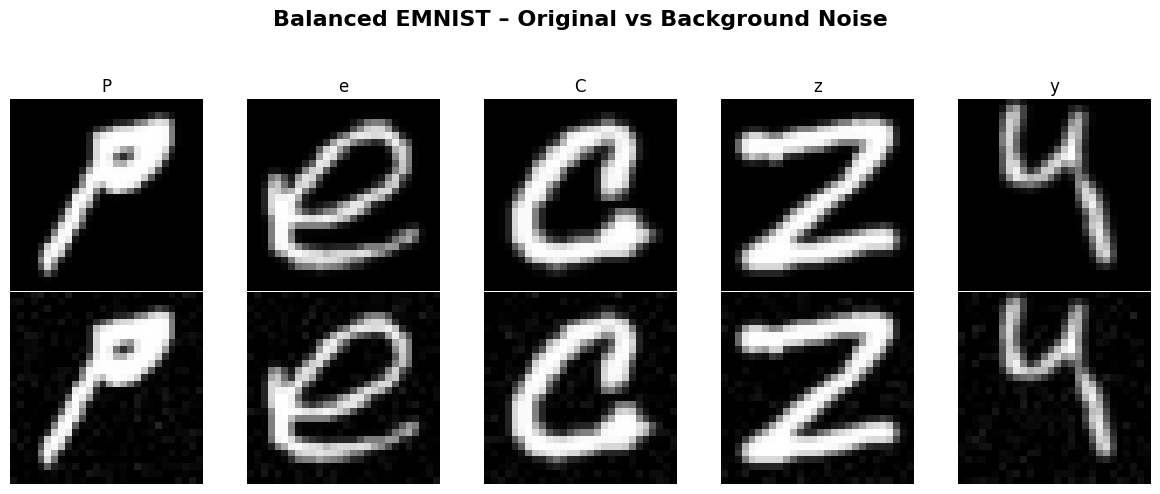


Saved noisy dataset:
Train: 697872 images
Test: 116323 images


In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Add background noise
def add_background_noise(img, noise_std=10):
    h, w = img.shape
    noise = np.random.normal(0, noise_std, (h, w))
    mask = (img > 0).astype(np.float32)
    noisy_bg = img + noise * (1 - mask)
    noisy_bg = np.clip(noisy_bg, 0, 255)
    return noisy_bg.astype(np.uint8)

# Apply noise to the balanced dataset
print("Applying background noise to training data...")
train_images_noisy = np.array([add_background_noise(img) for img in train_images_balanced])
print("Applying background noise to test data...")
test_images_noisy = np.array([add_background_noise(img) for img in test_images_balanced])

# Show 5 original vs noisy images from balanced dataset
indices = np.random.choice(len(train_images_balanced), 5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12,5))
fig.suptitle("Balanced EMNIST – Original vs Background Noise", fontsize=16, fontweight='bold')

for i, idx in enumerate(indices):
    axes[0, i].imshow(train_images_balanced[idx], cmap='gray')
    axes[0, i].set_title(mapping[train_labels_balanced[idx]])
    axes[0, i].axis('off')

for i, idx in enumerate(indices):
    axes[1, i].imshow(train_images_noisy[idx], cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("BG Noise", fontsize=12)

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

# Save noisy datasets (FIXED: was saving original images instead of noisy)
save_images_ubyte(train_images_noisy, "../data/noisy/emnist-byclass-train-images-idx3-ubyte")
save_labels_ubyte(train_labels_balanced, "../data/noisy/emnist-byclass-train-labels-idx1-ubyte")
save_images_ubyte(test_images_noisy, "../data/noisy/emnist-byclass-test-images-idx3-ubyte")
save_labels_ubyte(test_labels_balanced, "../data/noisy/emnist-byclass-test-labels-idx1-ubyte")

print(f"\nSaved noisy dataset:")
print(f"Train: {train_images_noisy.shape[0]} images")
print(f"Test: {test_images_noisy.shape[0]} images")

In [72]:
import zipfile

# Zip folder
base_dir = "../data"
folders_to_zip = ["original", "balanced", "noisy"]

for folder in folders_to_zip:
    folder_path = os.path.join(base_dir, folder)
    zip_path = os.path.join(base_dir, f"{folder}.zip")  
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, base_dir)
                zipf.write(file_path, arcname)
    print(f"Zip created at '{zip_path}'")


Zip created at '../data\original.zip'
Zip created at '../data\balanced.zip'
Zip created at '../data\noisy.zip'
